In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import pickle

In [3]:
df = pd.read_csv("../data/dataset.csv")

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [5]:
X = df.drop("Species", axis=1)
y = df["Species"]

In [6]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [7]:
# Apply PCA
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

In [8]:
# Explained Variance
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.7470533  0.18435257]


In [9]:
# Create PCA DataFrame
pca_df = pd.DataFrame(
    data=X_pca,
    columns=["PC1", "PC2"]
)

pca_df["Species"] = y

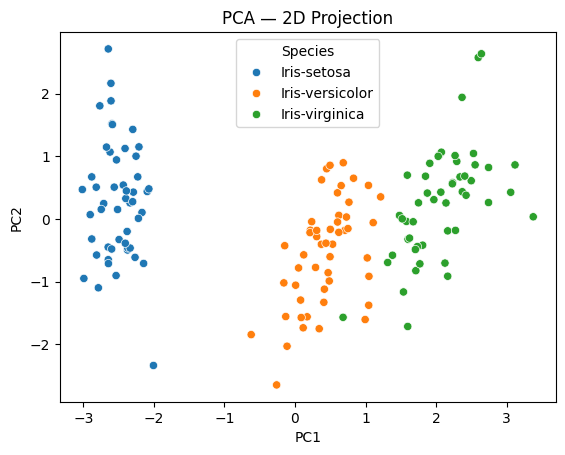

In [11]:
# Visualization
sns.scatterplot(
    x="PC1",
    y="PC2",
    hue="Species",
    data=pca_df
)

plt.title("PCA — 2D Projection")
plt.show()

In [12]:
with open("../model/pca_model.pkl", "wb") as f:
    pickle.dump(pca, f)

with open("../model/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

In [15]:
sample_data = [[5.1, 3.5, 1.4, 0.2, 0.0]]

feature_names = scaler.feature_names_in_
sample_df = pd.DataFrame(sample_data, columns=feature_names)
sample_scaled = scaler.transform(sample_df)
sample_pca = pca.transform(sample_scaled)

print("PCA Coordinates:", sample_pca)

PCA Coordinates: [[-2.99368987 -4.74975859]]
